# Social Network Analysis
The positive interaction layer covers 100 states out of 195 states and observeres, with 148 edges and total sentiment of 54.566. The average sentiment of interactions between states is 0.369, indicate a moderate level.

In [ ]:
import pandas as pd
import networkx as nx
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# info
df = pd.read_csv('../data/layer1/layer1_backbone_pos.csv')

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row['s1'], row['s2'], weight=row['avg_score'])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
total_weight = sum([d['weight'] for u, v, d in G.edges(data=True)])
avg_weight = total_weight/num_edges

print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Strength: {total_weight:.3f}")
print(f"Average sweight: {avg_weight:.3f}")

Nodes: 100
Edges: 148
Strength: 54.566
Average sweight: 0.369


# Network Assessment
In this vein, the study first examined each layer through density, transitivity, mean distance, diameter, and global efficiency. The n

Density: 0.030
Transitivity: 0.171
Mean Distance: 4.826
Diameter: 12
Global Efficiency: 0.243


In [6]:
def network_measures(G):
    density = nx.density(G)
    transitivity = nx.transitivity(G)
    # in case that the shortest path is infinite if the network is not connected
    if nx.is_connected(G):
        mean_distance = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        mean_distance = nx.average_shortest_path_length(subgraph)
        diameter = nx.diameter(subgraph)
    global_eff = nx.global_efficiency(G)
    return density, transitivity, mean_distance, diameter, global_eff

metrics = network_measures(G)
print(f"Density: {metrics[0]:.3f}")
print(f"Transitivity: {metrics[1]:.3f}")
print(f"Mean Distance: {metrics[2]:.3f}")
print(f"Diameter: {metrics[3]}")
print(f"Global Efficiency: {metrics[4]:.3f}")


Density: 0.030
Transitivity: 0.171
Mean Distance: 4.826
Diameter: 12
Global Efficiency: 0.243


In [ ]:
def config_permutation_network_measures(G, n_perm=1000):
    degree_seq = [d for n, d in G.degree()]
    results = {'density': [], 'transitivity': [], 'mean_distance': [], 'diameter': [], 'global_efficiency': []}
    for _ in range(n_perm):
        # Configuration model
        G_conf = nx.configuration_model(degree_seq)
        G_conf = nx.Graph(G_conf)
        G_conf.remove_edges_from(nx.selfloop_edges(G_conf))
        density, transitivity, mean_distance, diameter, global_eff = network_measures(G_conf)
        results['density'].append(density)
        results['transitivity'].append(transitivity)
        results['mean_distance'].append(mean_distance)
        results['diameter'].append(diameter)
        results['global_efficiency'].append(global_eff)
    for k in results:
        results[k] = np.array(results[k]) # type:ignore
    return results

random.seed(42)
np.random.seed(42)
config_results = config_permutation_network_measures(G, n_perm=1000)

obs_density, obs_trans, obs_mean_dist, obs_diam, obs_eff = network_measures(G)

p_density = (np.sum(config_results['density'] >= obs_density) + 1) / (len(config_results['density']) + 1)
p_trans = (np.sum(config_results['transitivity'] >= obs_trans) + 1) / (len(config_results['transitivity']) + 1) # type:ignore
p_mean_dist = (np.sum(config_results['mean_distance'] <= obs_mean_dist) + 1) / (len(config_results['mean_distance']) + 1) # type:ignore
p_diam = (np.sum(config_results['diameter'] <= obs_diam) + 1) / (len(config_results['diameter']) + 1) # type:ignore
p_eff = (np.sum(config_results['global_efficiency'] >= obs_eff) + 1) / (len(config_results['global_efficiency']) + 1) # type:ignore

print(f'Density p-value: {p_density:.3f}')
print(f'Transitivity p-value: {p_trans:.3f}')
print(f'Mean distance p-value: {p_mean_dist:.3f}')
print(f'Diameter p-value: {p_diam:.3f}')
print(f'Global efficiency p-value: {p_eff:.3f}')


Density p-value: 0.006
Transitivity p-value: 0.001
Mean distance p-value: 1.000
Diameter p-value: 0.994
Global efficiency p-value: 0.948


In [20]:
print(f'Density permutation mean: {perm_results["density"].mean():.3f}') # type:ignore
print(f'Transitivity permutation mean: {perm_results["transitivity"].mean():.3f}') # type:ignore
print(f'Mean_distance permutation mean: {perm_results["mean_distance"].mean():.3f}') # type:ignore
print(f'Diameter permutation mean: {perm_results["diameter"].mean():.3f}') # type:ignore
print(f'Global_efficiency permutation mean: {perm_results["global_efficiency"].mean():.3f}') # type:ignore

Density permutation mean: 0.030
Transitivity permutation mean: 0.047
Mean_distance permutation mean: 3.926
Diameter permutation mean: 8.994
Global_efficiency permutation mean: 0.276


# Community Detection
Heatmap (weight + density)


In [5]:
communities = nx.community.louvain_communities(G, weight='weight', seed=42)
partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i
modularity = nx.community.modularity(G, communities, weight='weight')

print(f"Detected communities: {len(communities)}")
print(f"Weighted modularity: {modularity:.3f}")

Detected communities: 13
Weighted modularity: 0.703


In [12]:
def calculate_weighted_ei(G, partition):
    # 1. 初始化全局和局部的权重计数
    total_w_internal = 0
    total_w_external = 0
    
    community_ids = sorted(list(set(partition.values())))
    comm_stats = {cid: {'I_w': 0, 'E_w': 0} for cid in community_ids}

    # 2. 遍历所有边，累加情感指数（权重）
    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)
        comm_u = partition[u]
        comm_v = partition[v]
        
        if comm_u == comm_v:
            total_w_internal += weight
            comm_stats[comm_u]['I_w'] += weight
        else:
            total_w_external += weight
            comm_stats[comm_u]['E_w'] += weight
            comm_stats[comm_v]['E_w'] += weight

    # 3. 计算全局加权 E-I Index
    # 公式: (E - I) / (E + I)
    global_weighted_ei = (total_w_external - total_w_internal) / (total_w_external + total_w_internal)
    
    # 4. 整理各社区详细数据
    details = []
    for cid in community_ids:
        Iw = comm_stats[cid]['I_w']
        Ew = comm_stats[cid]['E_w']
        # 局部 EI 反映该社区的情感开放度
        ei_local = (Ew - Iw) / (Ew + Iw) if (Ew + Iw) > 0 else 0
        details.append({
            'Community': f"Comm {cid}",
            'Internal_Weight_Sum': Iw,
            'External_Weight_Sum': Ew,
            'Weighted_EI': ei_local
        })

    df_details = pd.DataFrame(details)
    
    print(f"=== Global Weighted E-I Analysis ===")
    print(f"Total Internal Weight (I): {total_w_internal:.2f}")
    print(f"Total External Weight (E): {total_w_external:.2f}")
    print(f"Global Weighted E-I Index: {global_weighted_ei:.4f}")
    print("=====================================")
    
    return global_weighted_ei, df_details

# 运行计算
global_wei, df_wei = calculate_weighted_ei(G, partition)
print(df_wei)

=== Global Weighted E-I Analysis ===
Total Internal Weight (I): 45.42
Total External Weight (E): 9.15
Global Weighted E-I Index: -0.6646
   Community  Internal_Weight_Sum  External_Weight_Sum  Weighted_EI
0     Comm 0             8.171524             2.514444    -0.529393
1     Comm 1             0.121290             0.000000    -1.000000
2     Comm 2             5.810409             4.029469    -0.180992
3     Comm 3             6.836957             3.691457    -0.298763
4     Comm 4             0.333333             0.090909    -0.571429
5     Comm 5             4.283333             0.285714    -0.874935
6     Comm 6             7.500000             1.535714    -0.660079
7     Comm 7             5.640863             3.058058    -0.296911
8     Comm 8             0.229010             0.000000    -1.000000
9     Comm 9             0.616667             0.309524    -0.331620
10   Comm 10             2.000000             0.071429    -0.931034
11   Comm 11             1.144444             0

In [14]:
def calculate_unweighted_ei_index(G, partition):
    # --- 1. 初始化统计变量 ---
    # 获取唯一的社区ID并排序
    comm_ids = sorted(list(set(partition.values())))
    num_comms = len(comm_ids)
    
    # 局部统计字典：{community_id: {'I': 0, 'E': 0}}
    comm_ei_details = {cid: {'I': 0, 'E': 0} for cid in comm_ids}
    
    # 全局统计变量
    global_internal_edges = 0
    global_external_edges = 0

    # --- 2. 遍历所有边进行计数 (拓扑结构导向) ---
    for u, v in G.edges():
        comm_u = partition[u]
        comm_v = partition[v]
        
        if comm_u == comm_v:
            # 内部边 (Internal)
            global_internal_edges += 1
            comm_ei_details[comm_u]['I'] += 1
        else:
            # 跨社区边 (External)
            global_external_edges += 1
            # 这条跨社区边同时属于两个社区的 E 计数
            comm_ei_details[comm_u]['E'] += 1
            comm_ei_details[comm_v]['E'] += 1

    # --- 3. 计算全局 E-I Index ---
    # 公式: (E - I) / (E + I)
    total_edges = global_external_edges + global_internal_edges
    if total_edges > 0:
        global_ei = (global_external_edges - global_internal_edges) / total_edges
    else:
        global_ei = 0.0

    # --- 4. 汇总详细 Details 表格 ---
    details_list = []
    for cid in comm_ids:
        I = comm_ei_details[cid]['I']
        E = comm_ei_details[cid]['E']
        # 计算局部 E-I 指数
        ei_local = (E - I) / (E + I) if (E + I) > 0 else 0.0
        details_list.append({
            'Community': f"Comm {cid}",
            'Internal_Edges_I': I,
            'External_Edges_E': E,
            'Local_EI_Index': round(ei_local, 4)
        })

    # 将 Details 转化为 Pandas DataFrame
    df_ei_details = pd.DataFrame(details_list)
    
    # 打印学术报告格式的结果
    print(f"--- Global Unweighted E-I Analysis (Krackhardt & Stern) ---")
    print(f"Number of Communities:   {num_comms}")
    print(f"Total Internal Edges (I): {global_internal_edges}")
    print(f"Total External Edges (E): {global_external_edges}")
    print(f"Global Unweighted EI:     {global_ei:.4f}")
    print("----------------------------------------------------------\n")
    
    return global_ei, df_ei_details

# === 运行计算 (假设你已经有了 G 和 partition 字典) ===
global_ei, ei_details_table = calculate_unweighted_ei_index(G, partition)

# 打印详细细节表供分析
print("Community E-I Index Details:")
print(ei_details_table.to_string(index=False)) # 不带索引打印

--- Global Unweighted E-I Analysis (Krackhardt & Stern) ---
Number of Communities:   13
Total Internal Edges (I): 110
Total External Edges (E): 38
Global Unweighted EI:     -0.4865
----------------------------------------------------------

Community E-I Index Details:
Community  Internal_Edges_I  External_Edges_E  Local_EI_Index
   Comm 0                20                12         -0.2500
   Comm 1                 1                 0         -1.0000
   Comm 2                18                15         -0.0909
   Comm 3                17                16         -0.0303
   Comm 4                 1                 1          0.0000
   Comm 5                11                 1         -0.8333
   Comm 6                 9                 4         -0.3846
   Comm 7                15                15          0.0000
   Comm 8                 2                 0         -1.0000
   Comm 9                 3                 2         -0.2000
  Comm 10                 2                 1   

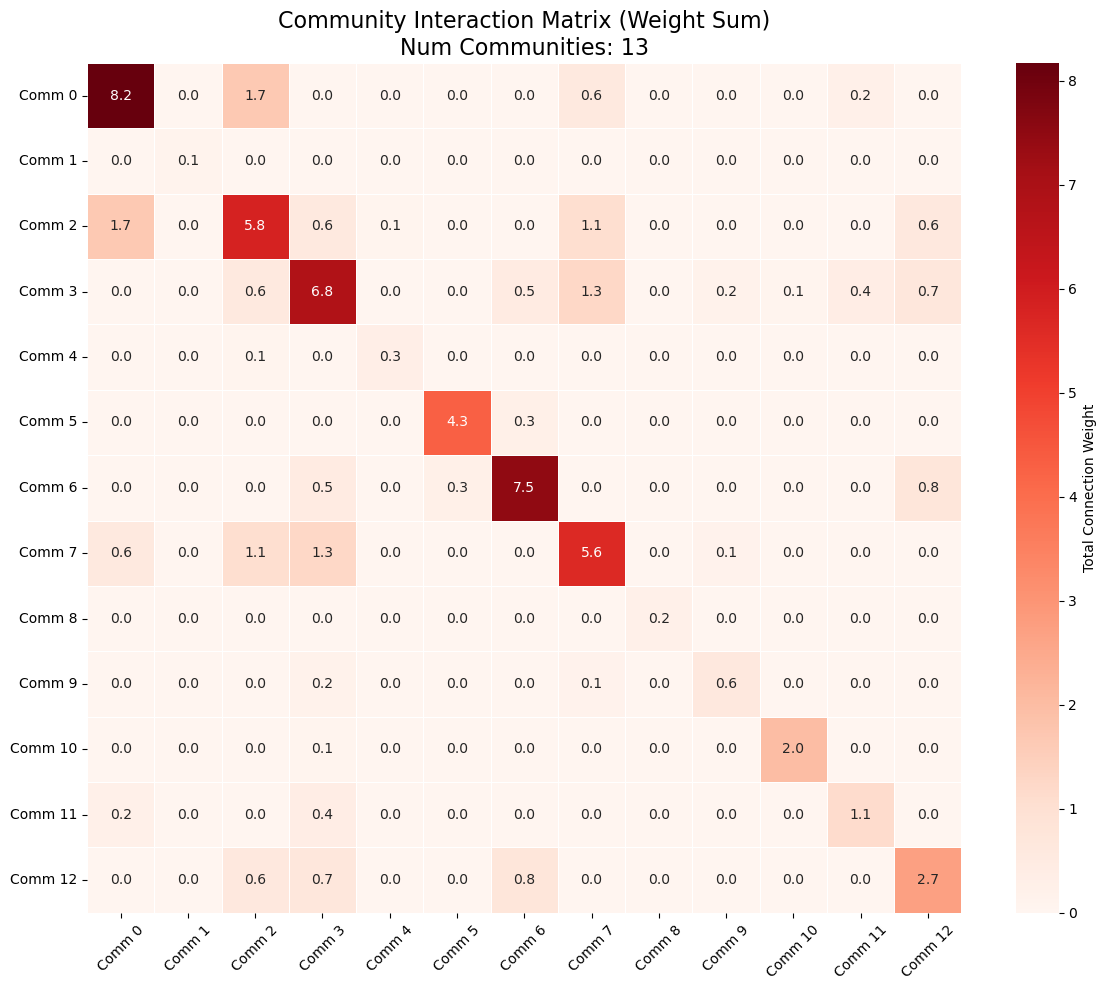

In [7]:
def plot_community_interaction_heatmap(G, partition):
    community_ids = sorted(list(set(partition.values())))
    num_communities = len(community_ids)
    
    interaction_matrix = np.zeros((num_communities, num_communities))
    
    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)
        comm_u = partition[u]
        comm_v = partition[v]
        
        interaction_matrix[comm_u][comm_v] += weight
        if comm_u != comm_v:
            interaction_matrix[comm_v][comm_u] += weight
            
    df_matrix = pd.DataFrame(
        interaction_matrix, 
        index=[f'Comm {i}' for i in community_ids],
        columns=[f'Comm {i}' for i in community_ids]
    )
    
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(df_matrix, annot=True, fmt='.1f', cmap='Reds', 
                linewidths=.5, cbar_kws={'label': 'Total Connection Weight'})
    
    plt.title(f"Community Interaction Matrix (Weight Sum)\nNum Communities: {num_communities}", fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_community_interaction_heatmap(G, partition)

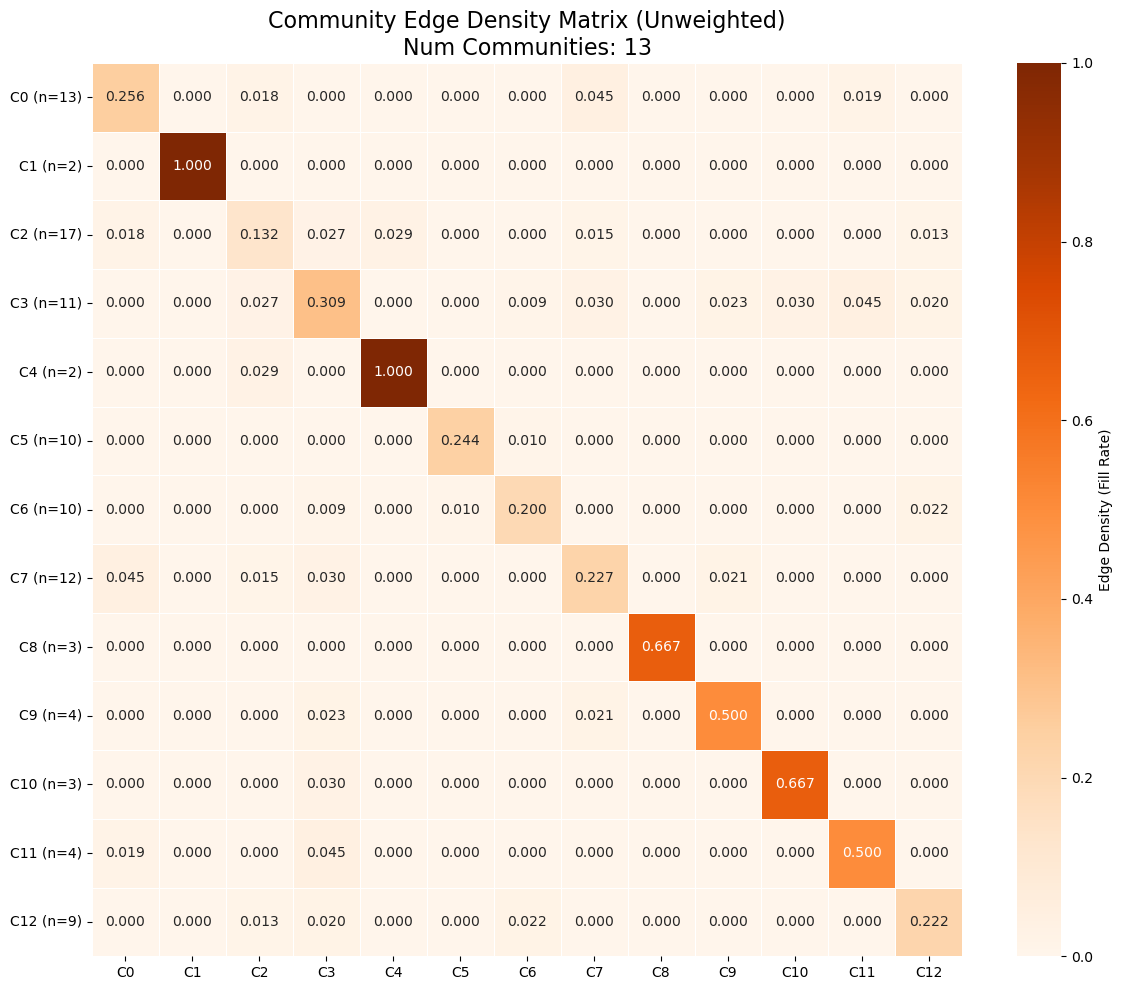

In [10]:
def plot_community_density_heatmap(G, partition):
    community_ids = sorted(list(set(partition.values())))
    num_communities = len(community_ids)
    
    # 1. 统计每个社区的节点数量
    comm_sizes = {cid: list(partition.values()).count(cid) for cid in community_ids}
    
    # 2. 统计实际存在的“边数” (不看权重)
    edge_count_matrix = np.zeros((num_communities, num_communities))
    for u, v in G.edges():
        comm_u = partition[u]
        comm_v = partition[v]
        
        edge_count_matrix[comm_u][comm_v] += 1
        if comm_u != comm_v:
            edge_count_matrix[comm_v][comm_u] += 1
            
    # 3. 计算普通密度 (实际边数 / 最大可能边数)
    density_matrix = np.zeros((num_communities, num_communities))
    for i in range(num_communities):
        for j in range(num_communities):
            s_i = comm_sizes[community_ids[i]]
            s_j = comm_sizes[community_ids[j]]
            
            if i == j:
                # 社区内部密度
                possible = s_i * (s_i - 1) / 2 if s_i > 1 else 1
            else:
                # 社区间密度
                possible = s_i * s_j
            
            density_matrix[i][j] = edge_count_matrix[i][j] / possible

    # 4. 绘图
    df_density = pd.DataFrame(
        density_matrix, 
        index=[f'C{i} (n={comm_sizes[i]})' for i in community_ids],
        columns=[f'C{i}' for i in community_ids]
    )
    
    plt.figure(figsize=(12, 10))
    # 普通密度通常在 0-1 之间，用 'Blues' 或 'YlGnBu' 视觉效果最好
    sns.heatmap(df_density, annot=True, fmt='.3f', cmap='Oranges', 
                linewidths=.5, cbar_kws={'label': 'Edge Density (Fill Rate)'})
    
    plt.title(f"Community Edge Density Matrix (Unweighted)\nNum Communities: {num_communities}", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_community_density_heatmap(G, partition)

# Node Identification